In [21]:
import numpy as np
import pandas as pd
from collections import deque
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
# Configuration
SIZE = 5
FEATURES = SIZE * SIZE

In [11]:
class HexBoard:
    def __init__(self, size=SIZE):
        self.size = size
        self.board = np.zeros((size, size), dtype=int) # 0: vide, 1: Bleu, 2: Rouge

    def get_neighbors(self, r, c):
        neighbors = []
        directions = [(-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0)]
        for dr, dc in directions:
            nr, nc = r + dr, c + dc
            if 0 <= nr < self.size and 0 <= nc < self.size:
                neighbors.append((nr, nc))
        return neighbors

    def check_win(self, player):
        # Bleu (1): Haut -> Bas | Rouge (2): Gauche -> Droite
        starts = [(0, c) for c in range(self.size) if self.board[0, c] == 1] if player == 1 \
                 else [(r, 0) for r in range(self.size) if self.board[r, 0] == 2]
        
        queue = deque(starts)
        visited = set(starts)
        while queue:
            r, c = queue.popleft()
            if (player == 1 and r == self.size - 1) or (player == 2 and c == self.size - 1):
                return True
            for move in self.get_neighbors(r, c):
                if self.board[move] == player and move not in visited:
                    visited.add(move)
                    queue.append(move)
        return False

    def encode(self):
        # Encode en 50 features (ci_b, ci_r) 
        encoding = []
        for val in self.board.flatten():
            encoding.extend([1, 0] if val == 1 else ([0, 1] if val == 2 else [0, 0]))
        return encoding

In [12]:
def minimax(board, depth, alpha, beta, is_maximizing):
    if board.check_win(1): return 1
    if board.check_win(2): return -1
    if depth == 0: return 0 

    empty_cells = list(zip(*np.where(board.board == 0)))
    if not empty_cells: return 0

    if is_maximizing:
        best = -float('inf')
        for r, c in empty_cells:
            board.board[r, c] = 1
            val = minimax(board, depth - 1, alpha, beta, False)
            board.board[r, c] = 0
            best = max(best, val)
            alpha = max(alpha, best)
            if beta <= alpha: break
        return best
    else:
        best = float('inf')
        for r, c in empty_cells:
            board.board[r, c] = 2
            val = minimax(board, depth - 1, alpha, beta, True)
            board.board[r, c] = 0
            best = min(best, val)
            beta = min(beta, best)
            if beta <= alpha: break
        return best

In [13]:
data = []
num_games = 100 # Augmente ce nombre pour un dataset plus solide

for _ in tqdm(range(num_games)):
    game = HexBoard()
    turn = 1
    while not game.check_win(1) and not game.check_win(2) and 0 in game.board:
        # On n'enregistre que les états où c'est au tour de Bleu (équivalent X) [cite: 22]
        if turn == 1:
            state = game.encode()
            # On utilise une profondeur de 3 pour rester rapide sur 5x5
            res = minimax(game, 3, -float('inf'), float('inf'), True)
            label = 1 if res > 0 else 0
            data.append(state + [label])
        
        # Jouer un coup (mélange d'aléatoire et de logique simple)
        empty = list(zip(*np.where(game.board == 0)))
        r, c = random.choice(empty)
        game.board[r, c] = turn
        turn = 3 - turn # Switch entre 1 et 2

100%|██████████| 100/100 [00:03<00:00, 27.85it/s]


In [14]:
def augment_by_symmetry(data_list):
    augmented_data = []
    for row in data_list:
        # 1. Ajouter l'état original
        augmented_data.append(row)
        
        # 2. Création de la symétrie :
        # On récupère les features (50) et le label (1)
        features = row[:50]
        label = row[50]
        
        # Reconstruction de la grille 5x5 pour manipulation facile
        # Chaque case a 2 bits : [bleu, rouge]
        grid = []
        for i in range(0, 50, 2):
            grid.append(features[i:i+2])
        grid = np.array(grid).reshape(5, 5, 2)
        
        # Transposition de la grille (Symétrie par rapport à la diagonale)
        transposed_grid = np.transpose(grid, (1, 0, 2))
        
        # Inversion des rôles : 
        # Si la case était [1, 0] (Bleu), elle devient [0, 1] (Rouge)
        # Le label 'blue_wins' s'inverse aussi car on regarde le miroir
        new_features = []
        for r in range(5):
            for c in range(5):
                val = transposed_grid[r, c]
                # Inversion : le bit Bleu devient le bit Rouge du miroir
                new_features.extend([val[1], val[0]])
        
        new_label = 1 if label == 0 else 0
        augmented_data.append(new_features + [new_label])
        
    return augmented_data

# Application
data_augmented = augment_by_symmetry(data)
print(f"Ancien total : {len(data)} | Nouveau total : {len(data_augmented)}")

Ancien total : 1104 | Nouveau total : 2208


In [17]:
cols = []
for i in range(25):
    cols.extend([f'c{i}_b', f'c{i}_r'])
cols.append('blue_wins')

df = pd.DataFrame(data_augmented, columns=cols)
df.to_csv('ressources/dataset.csv', index=False)
print(f"Dataset généré : {len(df)} lignes.")
df.head()

Dataset généré : 2208 lignes.


,c0_b,c0_r,c1_b,c1_r,c2_b,c2_r,c3_b,c3_r,c4_b,c4_r,...,c20_r,c21_b,c21_r,c22_b,c22_r,c23_b,c23_r,c24_b,c24_r,blue_wins
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0


In [19]:
# EDA

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Séparation des données
X = df.drop('blue_wins', axis=1)
y = df['blue_wins']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraînement
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

# Évaluation
y_pred = model_lr.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.52      0.56       223
           1       0.57      0.66      0.61       219

    accuracy                           0.59       442
   macro avg       0.59      0.59      0.58       442
weighted avg       0.59      0.59      0.58       442



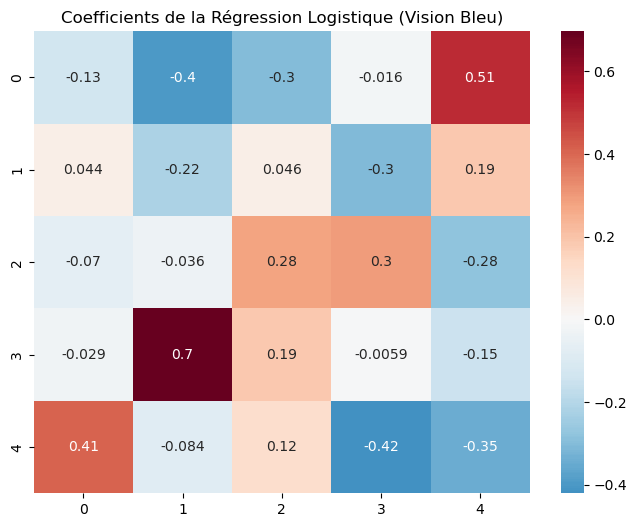

In [22]:
# Extraction des coefficients pour les cases "Bleu" (indices pairs : 0, 2, 4...)
coefs_bleu = model_lr.coef_[0][::2].reshape(5, 5)

plt.figure(figsize=(8, 6))
sns.heatmap(coefs_bleu, annot=True, cmap='RdBu_r', center=0)
plt.title("Coefficients de la Régression Logistique (Vision Bleu)")
plt.show()

In [23]:
# Amelioration en utilisant Random Forest

from sklearn.ensemble import RandomForestClassifier

# Entraînement du modèle avancé
model_rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
model_rf.fit(X_train, y_train)

# Évaluation
y_pred_rf = model_rf.predict(X_test)
print("--- Random Forest Results ---")
print(classification_report(y_test, y_pred_rf))

--- Random Forest Results ---
              precision    recall  f1-score   support

           0       0.83      0.70      0.76       223
           1       0.74      0.85      0.79       219

    accuracy                           0.78       442
   macro avg       0.78      0.78      0.78       442
weighted avg       0.78      0.78      0.77       442



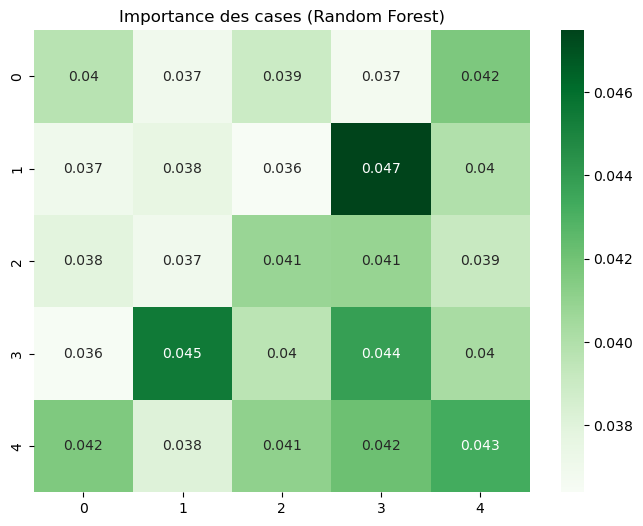

In [24]:
# On groupe l'importance par case (en additionnant le bit bleu et le bit rouge de chaque case)
importances = model_rf.feature_importances_
case_importance = np.zeros(25)
for i in range(25):
    case_importance[i] = importances[2*i] + importances[2*i+1]

plt.figure(figsize=(8, 6))
sns.heatmap(case_importance.reshape(5, 5), annot=True, cmap='Greens')
plt.title("Importance des cases (Random Forest)")
plt.show()